# Modeling HUPA0003's using an RNN, glucose are considered as the only input at each step t  

In addition, in this notebook we take an approach of the form sequence to vector i.e. given a sequence we predict just a single step instead of several steps 

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

## Get data 

In [3]:
data = pd.read_csv('../Data/Preprocessed/HUPA0003P.csv', sep=';')
data['time'] = pd.to_datetime(data['time'])

In [4]:
data

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input
0,2018-06-13 21:40:00,137.666667,7.32088,70.692308,8.0,0.075,0.0,0.0
1,2018-06-13 21:45:00,137.000000,11.19664,90.333333,17.0,0.075,0.0,0.0
2,2018-06-13 21:50:00,136.333333,8.18216,84.677419,0.0,0.075,0.0,0.0
3,2018-06-13 21:55:00,135.666667,8.82812,89.727273,8.0,0.075,0.0,0.0
4,2018-06-13 22:00:00,135.000000,6.67492,91.235294,0.0,0.075,0.0,0.0
...,...,...,...,...,...,...,...,...
3765,2018-06-26 23:25:00,160.666667,5.59674,68.875000,0.0,0.075,0.0,0.0
3766,2018-06-26 23:30:00,158.000000,5.48700,71.621622,0.0,0.075,0.0,0.0
3767,2018-06-26 23:35:00,159.000000,5.70648,71.692308,0.0,0.075,0.0,0.0
3768,2018-06-26 23:40:00,160.000000,5.48700,70.346154,0.0,0.075,0.0,0.0


## Architecture 

- input_size = 1 (Size of vector at each time step)
- hidden_size = 4 (Number of recurrent neurons)
- batch_size = 12

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

Prepare data 

Import our own class 

In [6]:
import sys
sys.path.append("..")
from scripts.window_regressor import Window_Regressor_Sequence_to_scalar

In [12]:
batch_size = 12
input_size = 1
hidden_size = 8
window_size = 4
steps_ahead = 3 

In [8]:
train = Window_Regressor_Sequence_to_scalar(data['glucose'][:-batch_size], window_size=window_size, horizon=steps_ahead).generate_data_set()
test = Window_Regressor_Sequence_to_scalar(data['glucose'][-batch_size:], window_size=window_size, horizon=steps_ahead).generate_data_set()

In [9]:
train_data = torch.tensor(train.values, dtype=torch.float32)
test_data = torch.tensor(test.values, dtype=torch.float32)

In [10]:
train_dataset = TensorDataset(train_data)
test_dataset = TensorDataset(test_data)
train_loader = DataLoader(train_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

Define the model

In [13]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn_1 = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.linear_layer = nn.Linear(in_features=hidden_size, out_features=1)
        
    
    def forward(self, x):
        output_recurrent_layer, _ = self.rnn_1(x) ## receives as input (Batch, Window, Input_size) => (Batch, Window, Hidden_size)
        prediction = self.linear_layer(output_recurrent_layer[:, -1, :])  ## We want to keep just the last output for the last element of each sequence 
        return prediction.squeeze(-1) ## To obtain (Batch,) instead of (Batch, 1)
        

In [ ]:
model = RNN(input_size=input_size, hidden_size=hidden_size)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_function = nn.MSELoss()
epochs = 500

In [17]:
print(model)

RNN(
  (rnn_1): LSTM(1, 8, batch_first=True)
  (linear_layer): Linear(in_features=8, out_features=1, bias=True)
)


Train the model 

In [18]:
train_losses = []
for e in range(epochs):
    epoch_losses = []
    for x in train_loader:
        batch = x[0]                
        x_in = batch[:, :-1]        ## to extract predictors 
        y = batch[:, -1]            # to etract label 
        x_in = x_in.unsqueeze(-1)  ## since torch receives an input (Batch,Window,Input_size=1) input size is equal to 1 cause we have an univariate time series 
        y_pred = model(x_in)        
        loss = loss_function(y_pred, y)
        epoch_losses.append(loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    avg_loss = sum(epoch_losses) / len(epoch_losses)
    train_losses.append(avg_loss)
    if e % 10 == 0:
        print(f'Epoch {e}/{epochs}, Average Loss: {avg_loss:.4f}')

Epoch 0/500, Average Loss: 24114.8094
Epoch 10/500, Average Loss: 20816.4847
Epoch 20/500, Average Loss: 18055.4893
Epoch 30/500, Average Loss: 15589.0863
Epoch 40/500, Average Loss: 13406.6663
Epoch 50/500, Average Loss: 11501.0423
Epoch 60/500, Average Loss: 9863.1146
Epoch 70/500, Average Loss: 8480.7359
Epoch 80/500, Average Loss: 6870.8881
Epoch 90/500, Average Loss: 5434.1207
Epoch 100/500, Average Loss: 4254.1567
Epoch 110/500, Average Loss: 3396.3487
Epoch 120/500, Average Loss: 2738.7918
Epoch 130/500, Average Loss: 2224.6159
Epoch 140/500, Average Loss: 1820.5481
Epoch 150/500, Average Loss: 1501.3428
Epoch 160/500, Average Loss: 1246.8296
Epoch 170/500, Average Loss: 1043.3703
Epoch 180/500, Average Loss: 881.8319
Epoch 190/500, Average Loss: 754.0909
Epoch 200/500, Average Loss: 652.6881
Epoch 210/500, Average Loss: 571.5558
Epoch 220/500, Average Loss: 505.2231
Epoch 230/500, Average Loss: 452.4570
Epoch 240/500, Average Loss: 409.4066
Epoch 250/500, Average Loss: 373.9151

Test the model

In [19]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

In [20]:
test

,Predictor_0,Predictor_1,Predictor_2,Predictor_3,Target
0,172.666667,173.333333,174.000000,171.333333,163.333333
1,173.333333,174.000000,171.333333,168.666667,160.666667
2,174.000000,171.333333,168.666667,166.000000,158.000000
3,171.333333,168.666667,166.000000,163.333333,159.000000
4,168.666667,166.000000,163.333333,160.666667,160.000000
5,166.000000,163.333333,160.666667,158.000000,161.000000


MAPE:0.02370244823396206
MAE:3.810765504837036
MSE:17.688613891601562


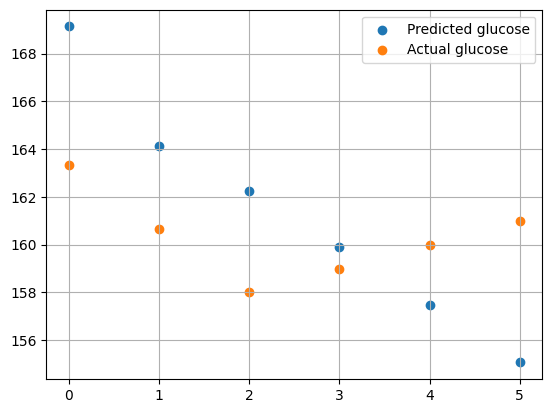

In [21]:
with torch.no_grad():
    for x in test_loader:
        batch = x[0]
        x = batch[:, :-1]
        y = batch[:, -1]
        output_model = model(x.unsqueeze(-1))
        mape = mean_absolute_percentage_error(y, output_model)
        mae = mean_absolute_error(y, output_model)
        mse = mean_squared_error(y, output_model)
        print(f'MAPE:{mape}')
        print(f'MAE:{mae}')
        print(f'MSE:{mse}')
        plt.scatter(range(y.size()[0]), output_model, label='Predicted glucose')
        plt.scatter(range(y.size()[0]), y, label='Actual glucose')
        plt.legend()
        plt.grid()
        plt.show()

Register our model using mlflow 

In [23]:
import mlflow
from mlflow import MlflowClient
from mlflow.models import infer_signature

In [24]:
params = {'batch_size' : batch_size, 
          'input_size' : input_size, 
          'hidden_size' : hidden_size, 
          'window_size' : window_size,
          'optimizer' : optimizer.__class__,
          'learning_rate' : 0.001,
          'loss_function' : loss_function.__class__,
          'epochs' : epochs,
          'steps_ahead' : steps_ahead
}
metrics = {'mae' : mae,
           'mape' : mape,
           'mse' : mse,
           'last_train_loss' : 157.8843
}

Just to log the model along with a signature 

In [25]:
example_input = torch.randn((batch_size, window_size, input_size))
example_output = model(example_input)
signature = infer_signature(example_input.numpy(), example_output.detach().numpy())

In [27]:
mlflow.set_tracking_uri(uri='http://127.0.0.1:8080')
mlflow.set_experiment('LSTM_two_recurrent_layers')
with mlflow.start_run(run_name='LSTM with just one recurrent layers'):
    mlflow.log_params(params)
    mlflow.log_metrics(metrics)
    mlflow.pytorch.log_model(model, 'lstm_one_layer', signature=signature)
    

2025/10/25 10:56:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/25 10:56:45 WARNING mlflow.utils.requirements_utils: Found torch version (2.8.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.8.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/10/25 10:56:49 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.23.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torchvision==0.23.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run LSTM with just one recurrent layers at: http://127.0.0.1:8080/#/experiments/398115710829462387/runs/bada6e2530254de99eb715a7ff7f64d1
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/398115710829462387


Now, let's try a recursive prediction 

In [ ]:
def predict_recursive(model, last_window, n_steps):
    with torch.no_grad():
        model.eval()
        window = last_window.clone().detach()  # (L,)
        predictions = []

        for _ in range(n_steps):
            # Preparar entrada: (1, L, 1) → batch=1, seq=L, features=1
            x = window.unsqueeze(0).unsqueeze(-1)  # (1, L, 1)
            
            with torch.no_grad():
                pred = model(x)  # (1,)
            
            pred_val = pred.item()
            predictions.append(pred_val)
            
            # Actualizar ventana: quitar el primero, añadir la predicción
            window = torch.cat([window[1:], torch.tensor([pred_val])])

        return predictions

In [ ]:
predict_recursive(model, last_window=torch.tensor([171.333333, 168.666667, 166.000000, 163.333333]), n_steps=6)

[160.6446533203125,
 157.5101776123047,
 153.43736267089844,
 147.66273498535156,
 139.4435272216797,
 129.49205017089844]

As we could see, recursive prediction does not perform well, since we are basically training our network to predict the next step even if we use a window